# HW12 – временные ряды: temporal split, baseline-модели и GRU-прогноз

Этот ноутбук:
- выполняет корректный `temporal split` на `train / validation / test`;
- считает baseline-модели `B1`, `B2`, `B3` и нейросетевой подход `R1 (GRU)`;
- сохраняет обязательные артефакты в `./artifacts/`.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

plt.style.use("seaborn-v0_8")

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Seed:", SEED)

Device: cpu
Seed: 42


In [3]:
ROOT = Path(".")
DATA_PATH = ROOT / "S12-hw-dataset.csv"
ARTIFACTS_DIR = ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
Пропуски по колонкам:


,na_count
date,0
target,0


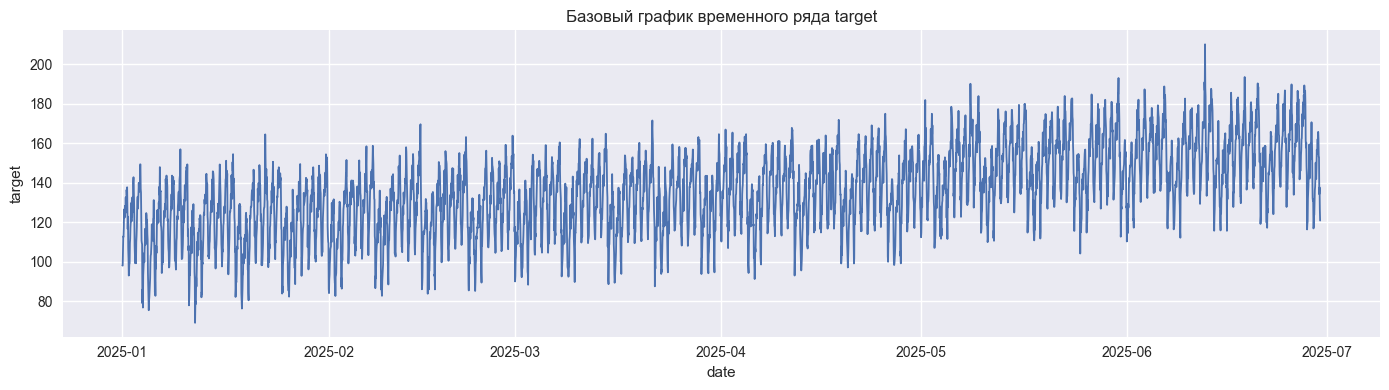

In [4]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

n_obs = len(df)
date_min = df["date"].min()
date_max = df["date"].max()
na_counts = df.isna().sum()

print("Число наблюдений:", n_obs)
print("Диапазон дат:", date_min, "->", date_max)
print("Пропуски по колонкам:")
display(na_counts.to_frame("na_count"))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["target"], lw=1.3)
ax.set_title("Базовый график временного ряда target")
ax.set_xlabel("date")
ax.set_ylabel("target")
fig.tight_layout()
plt.show()

In [5]:
print(
    "Визуально ряд демонстрирует выраженную внутридневную динамику (похожа на сезонность), "
    "возможный слабый тренд и шум. Это делает наивные прогнозы разумной отправной точкой, "
    "но лаговые/rolling признаки и рекуррентная модель могут дать преимущество."
)

Визуально ряд демонстрирует выраженную внутридневную динамику (похожа на сезонность), возможный слабый тренд и шум. Это делает наивные прогнозы разумной отправной точкой, но лаговые/rolling признаки и рекуррентная модель могут дать преимущество.


Split sizes: 3024 648 648
Train: 2025-01-01 00:00:00 -> 2025-05-06 23:00:00
Val  : 2025-05-07 00:00:00 -> 2025-06-02 23:00:00
Test : 2025-06-03 00:00:00 -> 2025-06-29 23:00:00


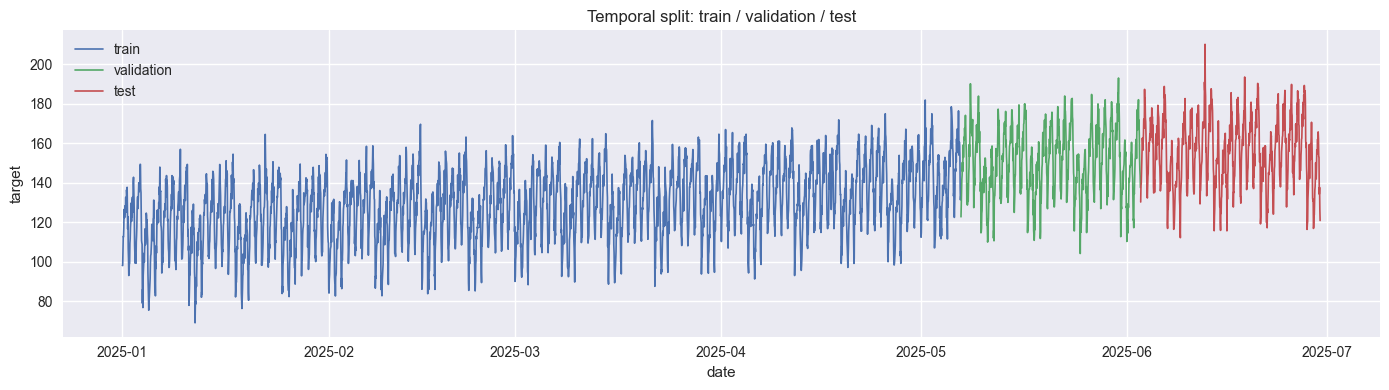

Почему random split некорректен: он смешивает прошлое и будущее между train/val/test, из-за чего оценка становится оптимистичной и не отражает реальный сценарий прогноза.


In [6]:
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

n = len(df)
train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

train_idx = np.arange(0, train_end)
val_idx = np.arange(train_end, val_end)
test_idx = np.arange(val_end, n)

print("Split sizes:", len(train_idx), len(val_idx), len(test_idx))
print("Train:", df.loc[train_idx[0], "date"], "->", df.loc[train_idx[-1], "date"])
print("Val  :", df.loc[val_idx[0], "date"], "->", df.loc[val_idx[-1], "date"])
print("Test :", df.loc[test_idx[0], "date"], "->", df.loc[test_idx[-1], "date"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.loc[train_idx, "date"], df.loc[train_idx, "target"], label="train", lw=1.2)
ax.plot(df.loc[val_idx, "date"], df.loc[val_idx, "target"], label="validation", lw=1.2)
ax.plot(df.loc[test_idx, "date"], df.loc[test_idx, "target"], label="test", lw=1.2)
ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("date")
ax.set_ylabel("target")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "series_split.png", dpi=150)
plt.show()

print(
    "Почему random split некорректен: он смешивает прошлое и будущее между train/val/test, "
    "из-за чего оценка становится оптимистичной и не отражает реальный сценарий прогноза."
)

### Возможные утечки данных (кратко)

- Лаги и rolling считаются только из прошлого (`shift`, скользящее окно по уже наблюдённым значениям).
- Масштабирование: отдельные вызовы `fit` только на train и `transform` на train/validation/test (см. ячейки с `x_scaler` и `y_scaler`).
- В `DataLoader` для временных окон используется `shuffle=False` (включая train), чтобы не перемешивать последовательности по времени.
- Test не используется для выбора модели и подбора гиперпараметров.


In [7]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    eps = 1e-8
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def calc_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(rmse(y_true, y_pred)),
        "mape": float(mape(y_true, y_pred)),
    }

In [8]:
feat_df = df.copy()
feat_df["lag_1"] = feat_df["target"].shift(1)
feat_df["lag_7"] = feat_df["target"].shift(7)
feat_df["lag_14"] = feat_df["target"].shift(14)
feat_df["rolling_mean_7"] = feat_df["target"].shift(1).rolling(window=7).mean()
feat_df["rolling_std_7"] = feat_df["target"].shift(1).rolling(window=7).std()
feat_df["day_of_week"] = feat_df["date"].dt.dayofweek
feat_df["hour"] = feat_df["date"].dt.hour
ma_window = 24
feat_df["moving_avg_24"] = feat_df["target"].shift(1).rolling(ma_window).mean()

feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week",
    "hour",
]
model_df = feat_df.dropna().reset_index(drop=True)

n2 = len(model_df)
tr_end2 = int(n2 * train_ratio)
val_end2 = int(n2 * (train_ratio + val_ratio))

tr2 = np.arange(0, tr_end2)
va2 = np.arange(tr_end2, val_end2)
te2 = np.arange(val_end2, n2)

y_all = model_df["target"].values
y_val = y_all[va2]
y_test = y_all[te2]

## B1 — baseline naive-last (последнее известное значение)


In [9]:
EXPERIMENT_B1 = "B1"
BASELINE_B1_NAIVE_LAST = "naive-last"
y_pred_b1_val = model_df["lag_1"].values[va2]
metrics_b1_val = calc_metrics(y_val, y_pred_b1_val)


## B2 — baseline moving-average (скользящее среднее)


In [10]:
EXPERIMENT_B2 = "B2"
BASELINE_B2_MOVING_AVERAGE = "moving-average"
y_pred_b2_val = model_df["moving_avg_24"].values[va2]
metrics_b2_val = calc_metrics(y_val, y_pred_b2_val)


In [11]:
EXPERIMENT_B3 = "B3"
X = model_df[feature_cols].copy()
y = model_df["target"].values

X_train, X_val, X_test = X.iloc[tr2], X.iloc[va2], X.iloc[te2]
y_train, y_val_b3, y_test_b3 = y[tr2], y[va2], y[te2]

x_scaler = StandardScaler()
x_scaler.fit(X_train)
X_train_sc = x_scaler.transform(X_train)
X_val_sc = x_scaler.transform(X_val)
X_test_sc = x_scaler.transform(X_test)

b3_model = Ridge(alpha=1.0, random_state=SEED)
b3_model.fit(X_train_sc, y_train)
y_pred_b3_val = b3_model.predict(X_val_sc)
metrics_b3_val = calc_metrics(y_val_b3, y_pred_b3_val)


In [12]:
series_df = df.copy()
series = series_df["target"].values.astype(np.float32)

n_s = len(series)
tr_end_s = int(n_s * train_ratio)
va_end_s = int(n_s * (train_ratio + val_ratio))
tr_s = np.arange(0, tr_end_s)
va_s = np.arange(tr_end_s, va_end_s)
te_s = np.arange(va_end_s, n_s)

y_scaler = StandardScaler()
train_slice = series[tr_s].reshape(-1, 1)
y_scaler.fit(train_slice)
train_scaled = y_scaler.transform(train_slice).squeeze(-1)
full_scaled = y_scaler.transform(series.reshape(-1, 1)).squeeze(-1)

WINDOW_SIZE = 48
HORIZON = 1


class SeqDataset(Dataset):
    def __init__(self, full_array, start_idx, end_idx, window_size):
        self.x = []
        self.y = []
        for t in range(start_idx, end_idx):
            left = t - window_size
            if left < 0:
                continue
            self.x.append(full_array[left:t])
            self.y.append(full_array[t])
        self.x = np.array(self.x, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return torch.from_numpy(self.x[idx]).unsqueeze(-1), torch.tensor(self.y[idx])


train_ds = SeqDataset(full_scaled, WINDOW_SIZE, tr_end_s, WINDOW_SIZE)
val_ds = SeqDataset(full_scaled, tr_end_s, va_end_s, WINDOW_SIZE)
test_ds = SeqDataset(full_scaled, va_end_s, n_s, WINDOW_SIZE)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Seq sizes:", len(train_ds), len(val_ds), len(test_ds))


Seq sizes: 2976 648 648


In [13]:
class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)


def evaluate_gru(model, loader, scaler):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model(xb)
            preds.append(pred.cpu().numpy())
            trues.append(yb.cpu().numpy())

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    preds_inv = scaler.inverse_transform(preds.reshape(-1, 1)).squeeze(-1)
    trues_inv = scaler.inverse_transform(trues.reshape(-1, 1)).squeeze(-1)
    return calc_metrics(trues_inv, preds_inv), trues_inv, preds_inv


gru_model = GRURegressor(hidden_size=64, num_layers=1).to(DEVICE)
optimizer = torch.optim.Adam(gru_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 40
patience = 8
best_val_mae = float("inf")
best_state = None
wait = 0
history = {"epoch": [], "train_loss": [], "val_mae": [], "val_rmse": [], "val_mape": []}

for epoch in range(1, EPOCHS + 1):
    gru_model.train()
    losses = []
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        pred = gru_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    train_loss = float(np.mean(losses))
    val_metrics, _, _ = evaluate_gru(gru_model, val_loader, y_scaler)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_mae"].append(val_metrics["mae"])
    history["val_rmse"].append(val_metrics["rmse"])
    history["val_mape"].append(val_metrics["mape"])

    if val_metrics["mae"] < best_val_mae:
        best_val_mae = val_metrics["mae"]
        best_state = {k: v.cpu().clone() for k, v in gru_model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

gru_model.load_state_dict(best_state)
metrics_r1_val, y_val_r1, y_pred_r1_val = evaluate_gru(gru_model, val_loader, y_scaler)
epochs_trained = len(history["epoch"])

torch.save(gru_model.state_dict(), ARTIFACTS_DIR / "best_gru.pt")

gru_config = {
    "model": "GRURegressor",
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 1,
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "lr": 1e-3,
    "max_epochs": EPOCHS,
    "epochs_trained": epochs_trained,
    "seed": SEED,
    "scaler": "StandardScaler(target, fit_on_train_only)",
    "device": str(DEVICE),
}
with open(ARTIFACTS_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(gru_config, f, ensure_ascii=False, indent=2)

,experiment_id,val_mae,val_rmse,val_mape
3,R1,5.082298,6.542812,3.438391
2,B3,6.370522,7.896932,4.285776
0,B1,6.444565,8.209954,4.395541
1,B2,13.446772,16.211041,9.227624


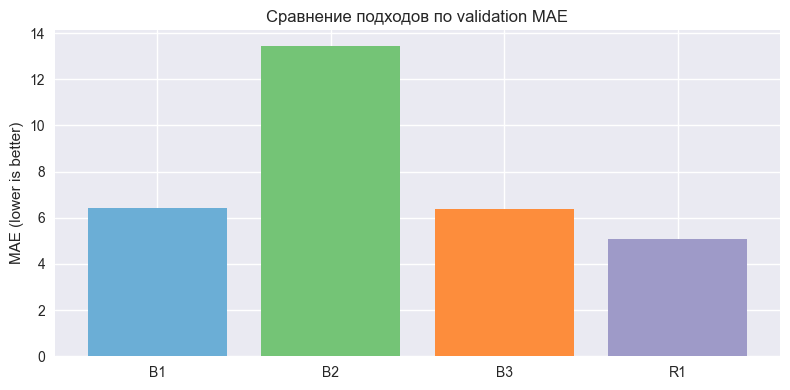

In [14]:
val_table = pd.DataFrame(
    [
        {
            "experiment_id": "B1",
            "val_mae": metrics_b1_val["mae"],
            "val_rmse": metrics_b1_val["rmse"],
            "val_mape": metrics_b1_val["mape"],
        },
        {
            "experiment_id": "B2",
            "val_mae": metrics_b2_val["mae"],
            "val_rmse": metrics_b2_val["rmse"],
            "val_mape": metrics_b2_val["mape"],
        },
        {
            "experiment_id": "B3",
            "val_mae": metrics_b3_val["mae"],
            "val_rmse": metrics_b3_val["rmse"],
            "val_mape": metrics_b3_val["mape"],
        },
        {
            "experiment_id": "R1",
            "val_mae": metrics_r1_val["mae"],
            "val_rmse": metrics_r1_val["rmse"],
            "val_mape": metrics_r1_val["mape"],
        },
    ]
)
display(val_table.sort_values("val_mae"))

fig, ax = plt.subplots(figsize=(8, 4))
order = ["B1", "B2", "B3", "R1"]
vals = [val_table.loc[val_table["experiment_id"] == e, "val_mae"].iloc[0] for e in order]
ax.bar(order, vals, color=["#6baed6", "#74c476", "#fd8d3c", "#9e9ac8"])
ax.set_title("Сравнение подходов по validation MAE")
ax.set_ylabel("MAE (lower is better)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "baselines_compare.png", dpi=150)
plt.show()

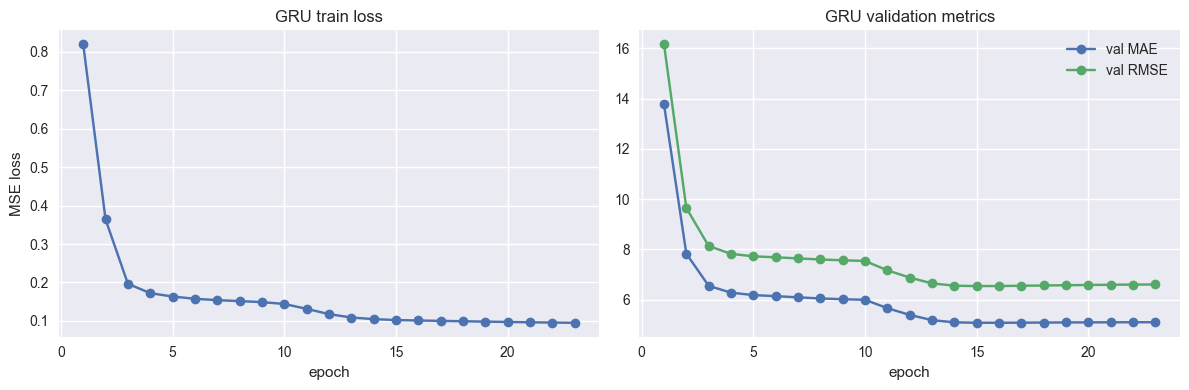

In [15]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o")
axes[0].set_title("GRU train loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss")

axes[1].plot(hist_df["epoch"], hist_df["val_mae"], marker="o", label="val MAE")
axes[1].plot(hist_df["epoch"], hist_df["val_rmse"], marker="o", label="val RMSE")
axes[1].set_title("GRU validation metrics")
axes[1].set_xlabel("epoch")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150)
plt.show()

Лучший подход по validation MAE: R1
Test metrics for best model: {'mae': 5.486122131347656, 'rmse': 7.03433742979194, 'mape': 3.5660054683685303}


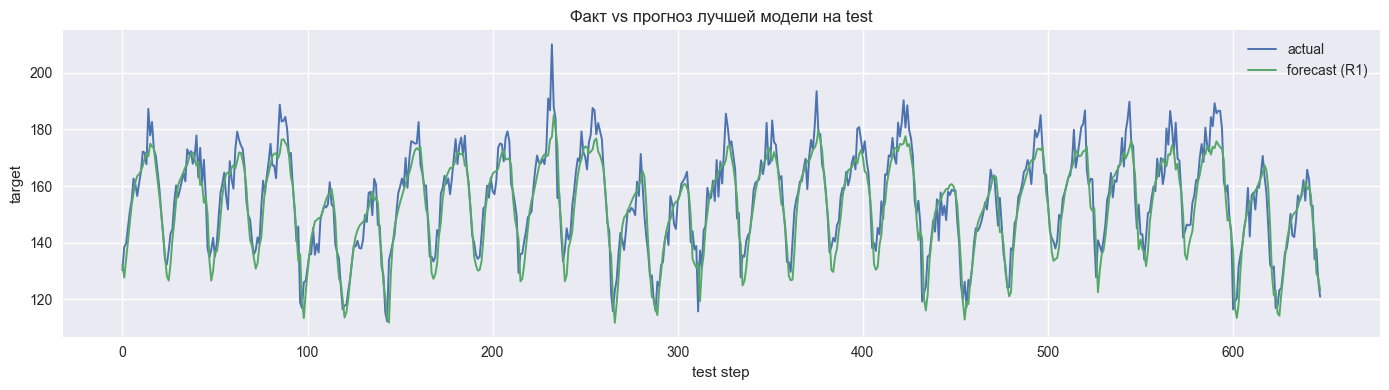

In [16]:
best_row = val_table.sort_values("val_mae").iloc[0]
best_exp = best_row["experiment_id"]
print("Лучший подход по validation MAE:", best_exp)

test_metrics = {"mae": None, "rmse": None, "mape": None}
test_true = None
test_pred = None

if best_exp == "B1":
    y_pred = model_df["lag_1"].values[te2]
    y_true = model_df["target"].values[te2]
    test_metrics = calc_metrics(y_true, y_pred)
    test_true, test_pred = y_true, y_pred
elif best_exp == "B2":
    y_pred = model_df["moving_avg_24"].values[te2]
    y_true = model_df["target"].values[te2]
    test_metrics = calc_metrics(y_true, y_pred)
    test_true, test_pred = y_true, y_pred
elif best_exp == "B3":
    y_pred = b3_model.predict(X_test_sc)
    y_true = y_test_b3
    test_metrics = calc_metrics(y_true, y_pred)
    test_true, test_pred = y_true, y_pred
else:
    test_metrics, y_true, y_pred = evaluate_gru(gru_model, test_loader, y_scaler)
    test_true, test_pred = y_true, y_pred

print("Test metrics for best model:", test_metrics)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_true, label="actual", lw=1.4)
ax.plot(test_pred, label=f"forecast ({best_exp})", lw=1.4)
ax.set_title("Факт vs прогноз лучшей модели на test")
ax.set_xlabel("test step")
ax.set_ylabel("target")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150)
plt.show()

In [17]:
split_summary = (
    f"temporal split ratios train/val/test={train_ratio:.2f}/{val_ratio:.2f}/{test_ratio:.2f}; "
    f"indices on raw df: [0:{train_end}), [{train_end}:{val_end}), [{val_end}:{len(df)})"
)
dataset_name = "S12-hw-dataset.csv"

rows = []
base_rows = {
    "B1": {
        "task": "forecasting",
        "dataset": dataset_name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": 1,
        "horizon": 1,
        "model_summary": "naive-last",
        "features_summary": "last observed target (lag_1)",
        "scaler": "",
        "optimizer": "",
        "lr": "",
        "epochs_trained": 0,
        "best_val_mae": metrics_b1_val["mae"],
        "best_val_rmse": metrics_b1_val["rmse"],
        "best_val_mape": metrics_b1_val["mape"],
        "notes": "No training. Forecast equals previous value.",
    },
    "B2": {
        "task": "forecasting",
        "dataset": dataset_name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": ma_window,
        "horizon": 1,
        "model_summary": "moving-average",
        "features_summary": f"rolling mean over last {ma_window} steps",
        "scaler": "",
        "optimizer": "",
        "lr": "",
        "epochs_trained": 0,
        "best_val_mae": metrics_b2_val["mae"],
        "best_val_rmse": metrics_b2_val["rmse"],
        "best_val_mape": metrics_b2_val["mape"],
        "notes": "No training. Uses shifted rolling mean.",
    },
    "B3": {
        "task": "forecasting",
        "dataset": dataset_name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": 14,
        "horizon": 1,
        "model_summary": "Ridge(alpha=1.0)",
        "features_summary": ",".join(feature_cols),
        "scaler": "StandardScaler(features, fit_on_train_only)",
        "optimizer": "",
        "lr": "",
        "epochs_trained": 1,
        "best_val_mae": metrics_b3_val["mae"],
        "best_val_rmse": metrics_b3_val["rmse"],
        "best_val_mape": metrics_b3_val["mape"],
        "notes": "Tabular lag/rolling/calendar baseline.",
    },
    "R1": {
        "task": "forecasting",
        "dataset": dataset_name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": WINDOW_SIZE,
        "horizon": HORIZON,
        "model_summary": "GRURegressor(hidden=64,layers=1)",
        "features_summary": "univariate target windows",
        "scaler": "StandardScaler(target, fit_on_train_only)",
        "optimizer": "Adam",
        "lr": 1e-3,
        "epochs_trained": epochs_trained,
        "best_val_mae": metrics_r1_val["mae"],
        "best_val_rmse": metrics_r1_val["rmse"],
        "best_val_mape": metrics_r1_val["mape"],
        "notes": "Best state_dict saved by validation MAE.",
    },
}

for exp_id in ["B1", "B2", "B3", "R1"]:
    row = {"experiment_id": exp_id}
    row.update(base_rows[exp_id])
    if exp_id == best_exp:
        row["test_mae"] = test_metrics["mae"]
        row["test_rmse"] = test_metrics["rmse"]
        row["test_mape"] = test_metrics["mape"]
    else:
        row["test_mae"] = ""
        row["test_rmse"] = ""
        row["test_mape"] = ""
    rows.append(row)

runs_df = pd.DataFrame(rows)
runs_path = ARTIFACTS_DIR / "runs.csv"
runs_df.to_csv(runs_path, index=False)
display(runs_df)
print("Saved:", runs_path)

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,notes,test_mae,test_rmse,test_mape
0,B1,forecasting,S12-hw-dataset.csv,42,temporal split ratios train/val/test=0.70/0.15...,1,1,naive-last,last observed target (lag_1),,,,0,6.444565,8.209954,4.395541,No training. Forecast equals previous value.,,,
1,B2,forecasting,S12-hw-dataset.csv,42,temporal split ratios train/val/test=0.70/0.15...,24,1,moving-average,rolling mean over last 24 steps,,,,0,13.446772,16.211041,9.227624,No training. Uses shifted rolling mean.,,,
2,B3,forecasting,S12-hw-dataset.csv,42,temporal split ratios train/val/test=0.70/0.15...,14,1,Ridge(alpha=1.0),"lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_...","StandardScaler(features, fit_on_train_only)",,,1,6.370522,7.896932,4.285776,Tabular lag/rolling/calendar baseline.,,,
3,R1,forecasting,S12-hw-dataset.csv,42,temporal split ratios train/val/test=0.70/0.15...,48,1,"GRURegressor(hidden=64,layers=1)",univariate target windows,"StandardScaler(target, fit_on_train_only)",Adam,0.001,23,5.082298,6.542812,3.438391,Best state_dict saved by validation MAE.,5.486122,7.034337,3.566005


Saved: artifacts\runs.csv
